# **Springboard Decision Tree Specialty Coffee Case Study - Tier 3**




# The Scenario

Imagine you've just finished the Springboard Data Science Career Track course, and have been hired by a rising popular specialty coffee company - RR Diner Coffee - as a data scientist. Congratulations!

RR Diner Coffee sells two types of thing:
- specialty coffee beans, in bulk (by the kilogram only) 
- coffee equipment and merchandise (grinders, brewing equipment, mugs, books, t-shirts).

RR Diner Coffee has three stores, two in Europe and one in the USA. The flagshap store is in the USA, and everything is quality assessed there, before being shipped out. Customers further away from the USA flagship store have higher shipping charges. 

You've been taken on at RR Diner Coffee because the company are turning towards using data science and machine learning to systematically make decisions about which coffee farmers they should strike deals with. 

RR Diner Coffee typically buys coffee from farmers, processes it on site, brings it back to the USA, roasts it, packages it, markets it, and ships it (only in bulk, and after quality assurance) to customers internationally. These customers all own coffee shops in major cities like New York, Paris, London, Hong Kong, Tokyo, and Berlin. 

Now, RR Diner Coffee has a decision about whether to strike a deal with a legendary coffee farm (known as the **Hidden Farm**) in rural China: there are rumours their coffee tastes of lychee and dark chocolate, while also being as sweet as apple juice. 

It's a risky decision, as the deal will be expensive, and the coffee might not be bought by customers. The stakes are high: times are tough, stocks are low, farmers are reverting to old deals with the larger enterprises and the publicity of selling *Hidden Farm* coffee could save the RR Diner Coffee business. 

Your first job, then, is ***to build a decision tree to predict how many units of the Hidden Farm Chinese coffee will be purchased by RR Diner Coffee's most loyal customers.*** 

To this end, you and your team have conducted a survey of 710 of the most loyal RR Diner Coffee customers, collecting data on the customers':
- age
- gender 
- salary 
- whether they have bought at least one RR Diner Coffee product online
- their distance from the flagship store in the USA (standardized to a number between 0 and 11) 
- how much they spent on RR Diner Coffee products on the week of the survey 
- how much they spent on RR Diner Coffee products in the month preeding the survey
- the number of RR Diner coffee bean shipments each customer has ordered over the preceding year. 

You also asked each customer participating in the survey whether they would buy the Hidden Farm coffee, and some (but not all) of the customers gave responses to that question. 

You sit back and think: if more than 70% of the interviewed customers are likely to buy the Hidden Farm coffee, you will strike the deal with the local Hidden Farm farmers and sell the coffee. Otherwise, you won't strike the deal and the Hidden Farm coffee will remain in legends only. There's some doubt in your mind about whether 70% is a reasonable threshold, but it'll do for the moment. 

To solve the problem, then, you will build a decision tree to implement a classification solution. 


-------------------------------
As ever, this notebook is **tiered**, meaning you can elect that tier that is right for your confidence and skill level. There are 3 tiers, with tier 1 being the easiest and tier 3 being the hardest. This is ***tier 3***, so it will be challenging. 

**1. Sourcing and loading** 
- Import packages
- Load data
- Explore the data

 
**2. Cleaning, transforming and visualizing**
- Cleaning the data
- Train/test split
  
  
**3. Modelling** 
- Model 1: Entropy model - no max_depth
- Model 2: Gini impurity model - no max_depth
- Model 3: Entropy model - max depth 3
- Model 4: Gini impurity model - max depth 3


**4. Evaluating and concluding** 
- How many customers will buy Hidden Farm coffee?
- Decision

**5. Random Forest** 
- Import necessary modules
- Model
- Revise conclusion
    

# 0. Overview

This notebook uses decision trees to determine whether the factors of salary, gender, age, how much money the customer spent last week and during the preceding month on RR Diner Coffee products, how many kilogram coffee bags the customer bought over the last year, whether they have bought at least one RR Diner Coffee product online, and their distance from the flagship store in the USA, could predict whether customers would purchase the Hidden Farm coffee if a deal with its farmers were struck. 

# 1. Sourcing and loading
## 1a. Import Packages

In [163]:
!pip install pydotplus

In [164]:
import pandas as pd
import numpy as np
from sklearn import tree, metrics
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO  
from IPython.display import Image  
import pydotplus

## 1b. Load data 

In [165]:
# Read in the data to a variable called coffeeData
RRD = pd.read_csv("data/RRDinerCoffeeData.csv")

## 1c. Explore the data

As we've seen, exploration entails doing things like checking out the **initial appearance** of the data with head(), the **dimensions** of our data with .shape, the **data types** of the variables with .info(), the **number of non-null values**, how much **memory** is being used to store the data, and finally the major summary statistcs capturing **central tendancy, dispersion and the null-excluding shape of the dataset's distribution**. 

How much of this can you do yourself by this point in the course? Have a real go. 

In [166]:
# Call head() on your data 
print(RRD.head())

   Age  Gender  num_coffeeBags_per_year  spent_week  spent_month  SlrAY  \
0   36  Female                        0          24           73  42789   
1   24    Male                        0          44          164  74035   
2   24    Male                        0          39          119  30563   
3   20    Male                        0          30          107  13166   
4   24  Female                        0          20           36  14244   

   Distance  Online  Decision  
0  0.003168       0       1.0  
1  0.520906       0       NaN  
2  0.916005       1       1.0  
3  0.932098       1       NaN  
4  0.965881       0       1.0  


In [167]:
# Call .shape on your data
RRD.shape

(702, 9)

In [168]:
# Call info() on your data
RRD.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      702 non-null    int64  
 1   Gender                   702 non-null    object 
 2   num_coffeeBags_per_year  702 non-null    int64  
 3   spent_week               702 non-null    int64  
 4   spent_month              702 non-null    int64  
 5   SlrAY                    702 non-null    int64  
 6   Distance                 702 non-null    float64
 7   Online                   702 non-null    int64  
 8   Decision                 474 non-null    float64
dtypes: float64(2), int64(6), object(1)
memory usage: 49.5+ KB


In [169]:
# Call describe() on your data to get the relevant summary statistics for your data 
RRD.describe()

,Age,num_coffeeBags_per_year,spent_week,spent_month,SlrAY,Distance,Online,Decision
count,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000,474.000000
mean,34.243590,2.710826,32.853276,107.923077,43819.843305,4.559186,0.531339,0.639241
std,13.927945,1.593629,15.731878,55.348485,26192.626943,3.116275,0.499373,0.480728
min,16.000000,0.000000,0.000000,0.000000,1617.000000,0.003168,0.000000,0.000000
25%,23.000000,1.000000,24.250000,62.000000,22812.250000,1.877812,0.000000,0.000000
50%,28.000000,3.000000,36.000000,113.500000,41975.000000,4.196167,1.000000,1.000000
75%,46.000000,4.000000,43.000000,150.750000,60223.000000,6.712022,1.000000,1.000000
max,90.000000,5.000000,62.000000,210.000000,182058.000000,10.986203,1.000000,1.000000


# 2. Cleaning, transforming and visualizing
## 2a. Cleaning the data

Some datasets don't require any cleaning, but almost all do. This one does. We need to replace '1.0' and '0.0' in the 'Decision' column by 'YES' and 'NO' respectively, clean up the values of the 'gender' column, and change the column names to words which maximize meaning and clarity. 

First, let's change the name of `spent_week`, `spent_month`, and `SlrAY` to `spent_last_week` and `spent_last_month` and `salary` respectively.

In [170]:
# Check out the names of our data's columns 
RRD.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_week', 'spent_month',
       'SlrAY', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [171]:
# Make the relevant name changes to spent_week and spent_per_week.
RRD.rename(columns={'spent_week': 'spent_last_week',
                    'spent_month': 'spent_last_month',
                    'SlrAY': 'salary'}, inplace=True)


In [172]:
# Check out the column names
RRD.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_last_week',
       'spent_last_month', 'salary', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [173]:
# Let's have a closer look at the gender column. Its values need cleaning.
RRD['Gender'].value_counts()

Gender
Male      355
Female    340
female      1
F           1
f           1
FEMALE      1
MALE        1
male        1
M           1
Name: count, dtype: int64

In [174]:
# See the gender column's unique values 
RRD['Gender'].unique()

array(['Female', 'Male', 'female', 'F', 'f ', 'FEMALE', 'MALE', 'male',
       'M'], dtype=object)

We can see a bunch of inconsistency here.

Use replace() to make the values of the `gender` column just `Female` and `Male`.

In [175]:
# Replace all alternate values for the Female entry with 'Female'
RRD['Gender'] = RRD['Gender'].replace({
    'female': 'Female',
    'F': 'Female',
    'f': 'Female',
    'f ': 'Female',
    'FEMALE': 'Female',
    'MALE': 'Male',
    'male': 'Male',
    'M': 'Male'
})

In [176]:
# Check out the unique values for the 'gender' column
RRD['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [177]:
# Replace all alternate values with "Male"
#Oh...uh...already did that!

In [178]:
# Let's check the unique values of the column "gender"
#Yeah...did that

In [179]:
# Check out the unique values of the column 'Decision'
RRD['Gender'].unique()

array(['Female', 'Male'], dtype=object)

We now want to replace `1.0` and `0.0` in the `Decision` column by `YES` and `NO` respectively.

In [180]:
# Replace 1.0 and 0.0 by 'Yes' and 'No'
RRD['Decision'].replace({'Yes': 'YES', 'No': 'NO'}, inplace=True)

C:\Users\emcdo\AppData\Local\Temp\ipykernel_25744\1633547736.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  RRD['Decision'].replace({'Yes': 'YES', 'No': 'NO'}, inplace=True)


In [181]:
# Check that our replacing those values with 'YES' and 'NO' worked, with unique()
RRD['Decision'].unique()

array([ 1., nan,  0.])

## 2b. Train/test split
To execute the train/test split properly, we need to do five things: 
1. Drop all rows with a null value in the `Decision` column, and save the result as NOPrediction: a dataset that will contain all known values for the decision 
2. Visualize the data using scatter and boxplots of several variables in the y-axis and the decision on the x-axis
3. Get the subset of coffeeData with null values in the `Decision` column, and save that subset as Prediction
4. Divide the NOPrediction subset into X and y, and then further divide those subsets into train and test subsets for X and y respectively
5. Create dummy variables to deal with categorical inputs

### 1. Drop all null values within the `Decision` column, and save the result as NoPrediction

In [182]:
# NoPrediction will contain all known values for the decision
# Call dropna() on coffeeData, and store the result in a variable NOPrediction 
# Call describe() on the Decision column of NoPrediction after calling dropna() on coffeeData
NoPrediction = RRD.dropna(subset=['Decision'])
NoPrediction['Decision'].describe()

count    474.000000
mean       0.639241
std        0.480728
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Decision, dtype: float64

### 2. Visualize the data using scatter and boxplots of several variables in the y-axis and the decision on the x-axis

C:\Users\emcdo\AppData\Local\Temp\ipykernel_25744\4246950581.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NoPrediction['spent_last_week'] = pd.to_numeric(NoPrediction['spent_last_week'], errors='coerce')


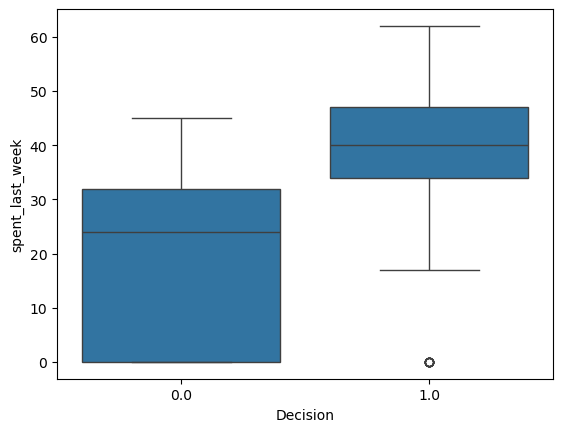

In [183]:
# Exploring our new NOPrediction dataset
# Make a boxplot on NOPrediction where the x axis is Decision, and the y axis is spent_last_week
NoPrediction['spent_last_week'] = pd.to_numeric(NoPrediction['spent_last_week'], errors='coerce')

sns.boxplot(x='Decision', y='spent_last_week', data=NoPrediction)
plt.show()

Can you admissibly conclude anything from this boxplot? Write your answer here:



In [184]:
#The median spending for the "YES" group is higher than that of the "NO" group, so we can reasonably conclude they spend more on average.

#There are no noteworthy, distinct outliers.

C:\Users\emcdo\AppData\Local\Temp\ipykernel_25744\1113062819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NoPrediction['Distance'] = pd.to_numeric(NoPrediction['Distance'], errors='coerce')
C:\Users\emcdo\AppData\Local\Temp\ipykernel_25744\1113062819.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  NoPrediction['spent_last_month'] = pd.to_numeric(NoPrediction['spent_last_month'], errors='coerce')


<Axes: xlabel='Distance', ylabel='spent_last_month'>

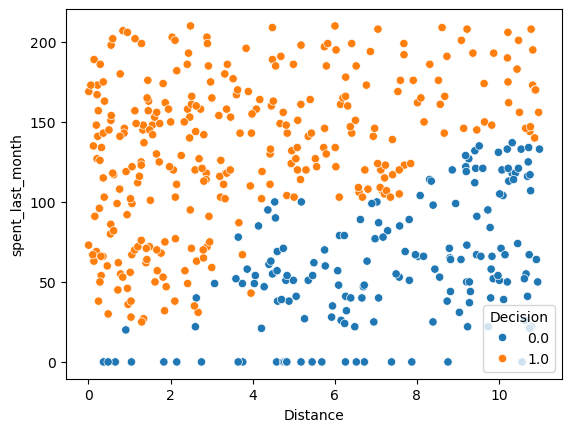

In [185]:
# Make a scatterplot on NOPrediction, where x is distance, y is spent_last_month and hue is Decision 
NoPrediction['Distance'] = pd.to_numeric(NoPrediction['Distance'], errors='coerce')
NoPrediction['spent_last_month'] = pd.to_numeric(NoPrediction['spent_last_month'], errors='coerce')

sns.scatterplot(x='Distance', y='spent_last_month', hue='Decision', data=NoPrediction)

Can you admissibly conclude anything from this scatterplot? Remember: we are trying to build a tree to classify unseen examples. Write your answer here:

In [186]:
#There is definitely a correlative relationship here.  
#The shorter the distance, the more likely a "yes" if more is spent last month.
#Conversely, the greater the distance, the more likely a "no" response depending on the amount spent last month.

### 3. Get the subset of coffeeData with null values in the Decision column, and save that subset as Prediction

In [187]:
# Get just those rows whose value for the Decision column is null  
Prediction = NoPrediction[NoPrediction['Decision'].isnull()]
print(Prediction)

Empty DataFrame
Columns: [Age, Gender, num_coffeeBags_per_year, spent_last_week, spent_last_month, salary, Distance, Online, Decision]
Index: []


In [188]:
# Call describe() on Prediction
Prediction.describe()

,Age,num_coffeeBags_per_year,spent_last_week,spent_last_month,salary,Distance,Online,Decision
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4. Divide the NOPrediction subset into X and y

In [189]:
# Check the names of the columns of NOPrediction
NoPrediction.columns

Index(['Age', 'Gender', 'num_coffeeBags_per_year', 'spent_last_week',
       'spent_last_month', 'salary', 'Distance', 'Online', 'Decision'],
      dtype='object')

In [190]:
# Let's do our feature selection.
# Make a variable called 'features', and a list containing the strings of every column except "Decision"
features = [col for col in NoPrediction.columns if col != 'Decision']

# Make an explanatory variable called X, and assign it: NoPrediction[features]
X = NoPrediction[features]

# Make a dependent variable called y, and assign it: NoPrediction.Decision
y = NoPrediction['Decision']


### 5. Create dummy variables to deal with categorical inputs
One-hot encoding replaces each unique value of a given column with a new column, and puts a 1 in the new column for a given row just if its initial value for the original column matches the new column. Check out [this resource](https://hackernoon.com/what-is-one-hot-encoding-why-and-when-do-you-have-to-use-it-e3c6186d008f) if you haven't seen one-hot-encoding before. 

**Note**: We will do this before we do our train/test split as to do it after could mean that some categories only end up in the train or test split of our data by chance and this would then lead to different shapes of data for our `X_train` and `X_test` which could/would cause downstream issues when fitting or predicting using a trained model.

In [191]:
# One-hot encode all features in X.
X_encoded = pd.get_dummies(X, drop_first=True)


### 6. Further divide those subsets into train and test subsets for X and y respectively: X_train, X_test, y_train, y_test

In [192]:
# Call train_test_split on X, y. Make the test_size = 0.25, and random_state = 246
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=246)


# 3. Modelling
It's useful to look at the scikit-learn documentation on decision trees https://scikit-learn.org/stable/modules/tree.html before launching into applying them. If you haven't seen them before, take a look at that link, in particular the section `1.10.5.` 

## Model 1: Entropy model - no max_depth

We'll give you a little more guidance here, as the Python is hard to deduce, and scikitlearn takes some getting used to.

Theoretically, let's remind ourselves of what's going on with a decision tree implementing an entropy model.

Ross Quinlan's **ID3 Algorithm** was one of the first, and one of the most basic, to use entropy as a metric.

**Entropy** is a measure of how uncertain we are about which category the data-points fall into at a given point in the tree. The **Information gain** of a specific feature with a threshold (such as 'spent_last_month <= 138.0') is the difference in entropy that exists before and after splitting on that feature; i.e., the information we gain about the categories of the data-points by splitting on that feature and that threshold. 

Naturally, we want to minimize entropy and maximize information gain. Quinlan's ID3 algorithm is designed to output a tree such that the features at each node, starting from the root, and going all the way down to the leaves, have maximial information gain. We want a tree whose leaves have elements that are *homogeneous*, that is, all of the same category. 

The first model will be the hardest. Persevere and you'll reap the rewards: you can use almost exactly the same code for the other models. 

In [193]:
# Declare a variable called entr_model and use tree.DecisionTreeClassifier. 
entr_model = tree.DecisionTreeClassifier()

# Call fit() on entr_model
entr_model.fit(X_train, y_train)

# Call predict() on entr_model with X_test passed to it, and assign the result to a variable y_pred 
y_pred = entr_model.predict(X_test)

# Call Series on our y_pred variable with the following: pd.Series(y_pred)
y_pred_series = pd.Series(y_pred)


# Check out entr_model
entr_model

DecisionTreeClassifier()

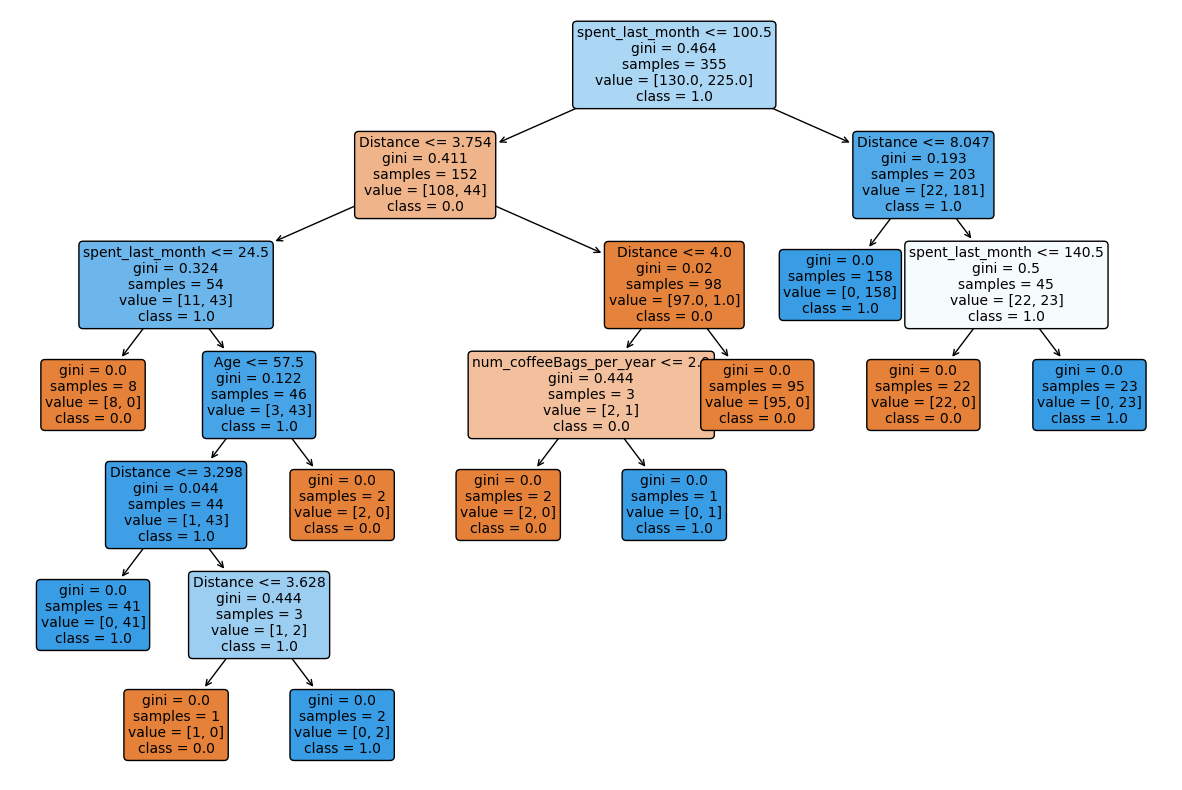

In [194]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(
    entr_model,
    feature_names=[str(col) for col in X_encoded.columns],
    class_names=[str(c) for c in entr_model.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

## Model 1: Entropy model - no max_depth: Interpretation and evaluation

In [195]:
# Run this block for model evaluation metrics 
y_test_str = y_test.map({1.0: "YES", 0.0: "NO"})
y_pred_str = pd.Series(y_pred).map({1.0: "YES", 0.0: "NO"})

print("Model Entropy - no max depth")
print("Accuracy:", metrics.accuracy_score(y_test_str, y_pred_str))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test_str, y_pred_str))
print('Precision score for "Yes":', metrics.precision_score(y_test_str, y_pred_str, pos_label="YES"))
print('Precision score for "No":', metrics.precision_score(y_test_str, y_pred_str, pos_label="NO"))
print('Recall score for "Yes":', metrics.recall_score(y_test_str, y_pred_str, pos_label="YES"))
print('Recall score for "No":', metrics.recall_score(y_test_str, y_pred_str, pos_label="NO"))

Model Entropy - no max depth
Accuracy: 0.9747899159663865
Balanced accuracy: 0.9691994996873046
Precision score for "Yes": 0.9746835443037974
Precision score for "No": 0.975
Recall score for "Yes": 0.9871794871794872
Recall score for "No": 0.9512195121951219


What can you infer from these results? Write your conclusions here:

In [247]:
#The model seems to have accurately classified just over 97% of cases.
#There is also a strong balance between "Yes" and "No," which I THINK means it is relatively unbiased between the two options
#The very high Precision score means very few false positive
#Conversely, the high Recall score indicates very few false negatives

## Model 2: Gini impurity model - no max_depth

Gini impurity, like entropy, is a measure of how well a given feature (and threshold) splits the data into categories.

Their equations are similar, but Gini impurity doesn't require logorathmic functions, which can be computationally expensive. 

In [196]:
y_train = y_train.astype(str)

In [197]:
# Make a variable called gini_model, and assign it exactly what you assigned entr_model with above, but with the
# criterion changed to 'gini'
gini_model = tree.DecisionTreeClassifier(criterion='gini')

# Call fit() on the gini_model as you did with the entr_model
gini_model.fit(X_train, y_train)

# Call predict() on the gini_model as you did with the entr_model 
y_pred_gini = gini_model.predict(X_test)

# Turn y_pred into a series, as before
y_pred_gini_series = pd.Series(y_pred_gini)

# Check out gini_model
print(gini_model)

DecisionTreeClassifier()


In [198]:
y_train

410    1.0
257    0.0
141    1.0
617    1.0
424    1.0
      ... 
326    1.0
523    1.0
179    1.0
209    0.0
609    1.0
Name: Decision, Length: 355, dtype: object

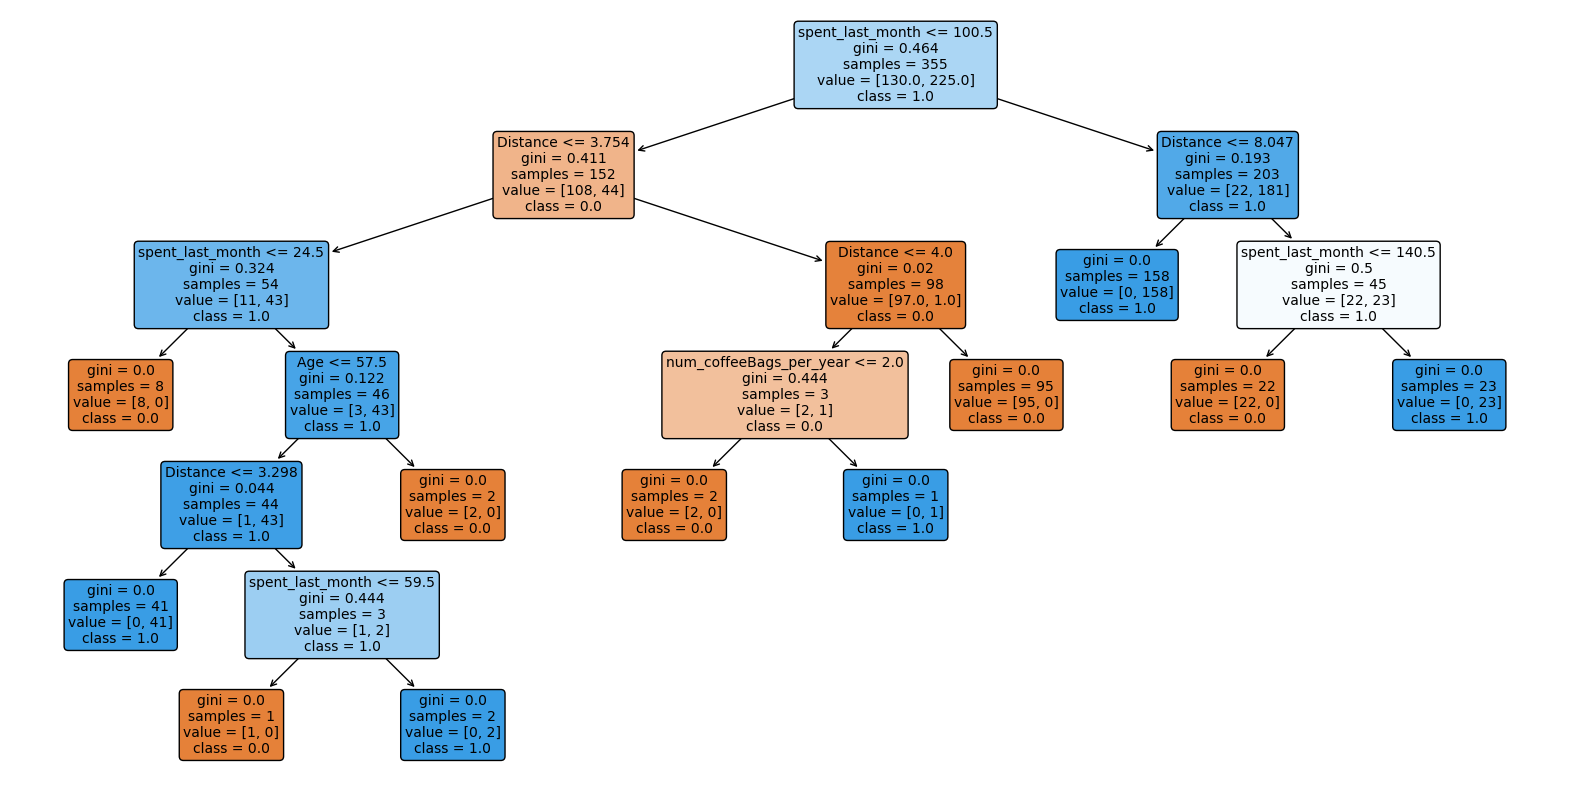

In [199]:
# As before, but make the model name gini_model

# Alternatively for class_names use gini_model.classes_

plt.figure(figsize=(20, 10))
plot_tree(
    gini_model,
    feature_names=X_encoded.columns,
    class_names=gini_model.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


In [201]:
y_test

66     1.0
87     1.0
117    0.0
173    0.0
538    0.0
      ... 
37     1.0
543    1.0
568    0.0
177    0.0
244    1.0
Name: Decision, Length: 119, dtype: float64

In [203]:
# Run this block for model evaluation
print("Model Gini impurity model")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score', metrics.precision_score(y_test, y_pred, pos_label=1.0))
print('Recall score', metrics.recall_score(y_test, y_pred, pos_label=1.0))

Model Gini impurity model
Accuracy: 0.9747899159663865
Balanced accuracy: 0.9691994996873046
Precision score 0.9746835443037974
Recall score 0.9871794871794872


How do the results here compare to the previous model? Write your judgements here: 

In [249]:
#The results look almost exactly the same!  I'm not sure if this means I did everything right...
#There is a differnce of less than a single percentage point between all 4 model metrics

## Model 3: Entropy model - max depth 3
We're going to try to limit the depth of our decision tree, using entropy first.  

As you know, we need to strike a balance with tree depth. 

Insufficiently deep, and we're not giving the tree the opportunity to spot the right patterns in the training data.

Excessively deep, and we're probably going to make a tree that overfits to the training data, at the cost of very high error on the (hitherto unseen) test data. 

Sophisticated data scientists use methods like random search with cross-validation to systematically find a good depth for their tree. We'll start with picking 3, and see how that goes. 

In [204]:
# Made a model as before, but call it entr_model2, and make the max_depth parameter equal to 3. 
# Execute the fitting, predicting, and Series operations as before
entr_model2 = tree.DecisionTreeClassifier(criterion='entropy', max_depth=3)
entr_model2.fit(X_train, y_train)
y_pred_entr2 = entr_model2.predict(X_test)
y_pred_entr2_series = pd.Series(y_pred_entr2)


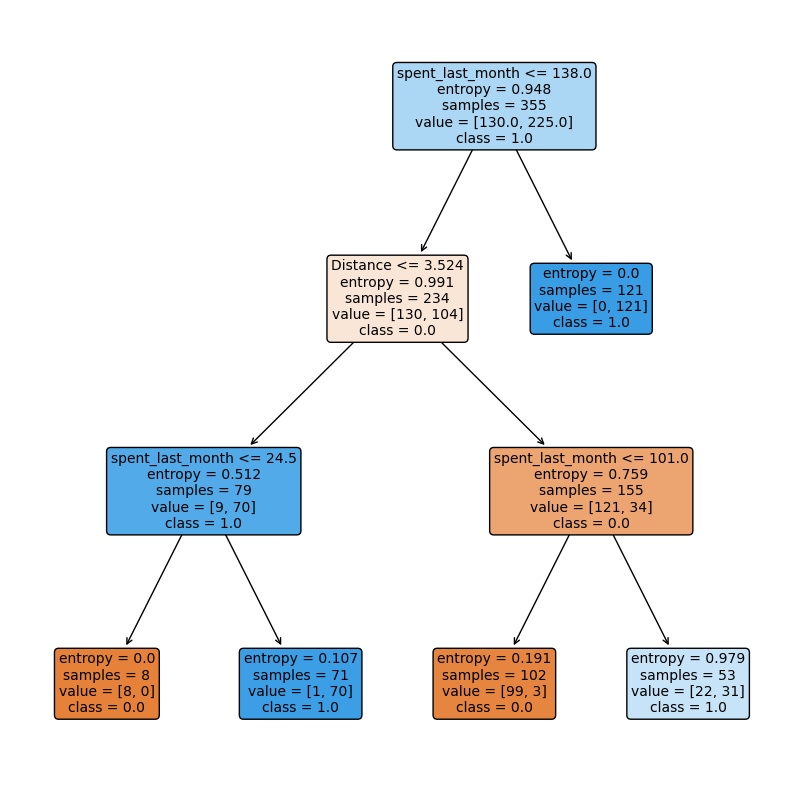

In [205]:
# As before, we need to visualize the tree to grasp its nature

# Alternatively for class_names use entr_model2.classes_

plt.figure(figsize=(10, 10))
plot_tree(
    entr_model2,
    feature_names=X_encoded.columns,
    class_names=entr_model2.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [207]:
# Run this block for model evaluation 
print("Model Entropy model max depth 3")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score', metrics.precision_score(y_test, y_pred, pos_label=1.0))
print('Recall score', metrics.recall_score(y_test, y_pred, pos_label=1.0))

Model Entropy model max depth 3
Accuracy: 0.9747899159663865
Balanced accuracy: 0.9691994996873046
Precision score 0.9746835443037974
Recall score 0.9871794871794872


So our accuracy decreased, but is this certainly an inferior tree to the max depth original tree we did with Model 1? Write your conclusions here: 

In [209]:
#The models have a comparable overall accuracy, balanced accuracy, preceision for 'yes,' and recall for 'no'
#I can't easily see how much memory it takes to run each, but the accuracy decrease for the Entropy model seems quite minor

## Model 4: Gini impurity  model - max depth 3
We're now going to try the same with the Gini impurity model. 

In [214]:
# As before, make a variable, but call it gini_model2, and ensure the max_depth parameter is set to 3
gini_model2 = tree.DecisionTreeClassifier(criterion='gini', max_depth=3)


# Do the fit, predict, and series transformations as before. 
#gini_model2.fit(X_train, y_train)
#y_pred_gini2 = gini_model2.predict(X_test)
#y_pred_gini2_series = pd.Series(y_pred_gini2)

gini_model2.fit(X_train, y_train)
y_pred_gini2 = gini_model2.predict(X_test)
y_pred_gini2_series = pd.Series(y_pred_gini2)


[Text(0.5416666666666666, 0.875, 'spent_last_month <= 100.5\ngini = 0.464\nsamples = 355\nvalue = [130.0, 225.0]\nclass = 1.0'),
 Text(0.3333333333333333, 0.625, 'Distance <= 3.754\ngini = 0.411\nsamples = 152\nvalue = [108, 44]\nclass = 0.0'),
 Text(0.16666666666666666, 0.375, 'spent_last_month <= 24.5\ngini = 0.324\nsamples = 54\nvalue = [11, 43]\nclass = 1.0'),
 Text(0.08333333333333333, 0.125, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]\nclass = 0.0'),
 Text(0.25, 0.125, 'gini = 0.122\nsamples = 46\nvalue = [3, 43]\nclass = 1.0'),
 Text(0.5, 0.375, 'Distance <= 4.0\ngini = 0.02\nsamples = 98\nvalue = [97.0, 1.0]\nclass = 0.0'),
 Text(0.4166666666666667, 0.125, 'gini = 0.444\nsamples = 3\nvalue = [2, 1]\nclass = 0.0'),
 Text(0.5833333333333334, 0.125, 'gini = 0.0\nsamples = 95\nvalue = [95, 0]\nclass = 0.0'),
 Text(0.75, 0.625, 'Distance <= 8.047\ngini = 0.193\nsamples = 203\nvalue = [22, 181]\nclass = 1.0'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 158\nvalue = [0, 158]

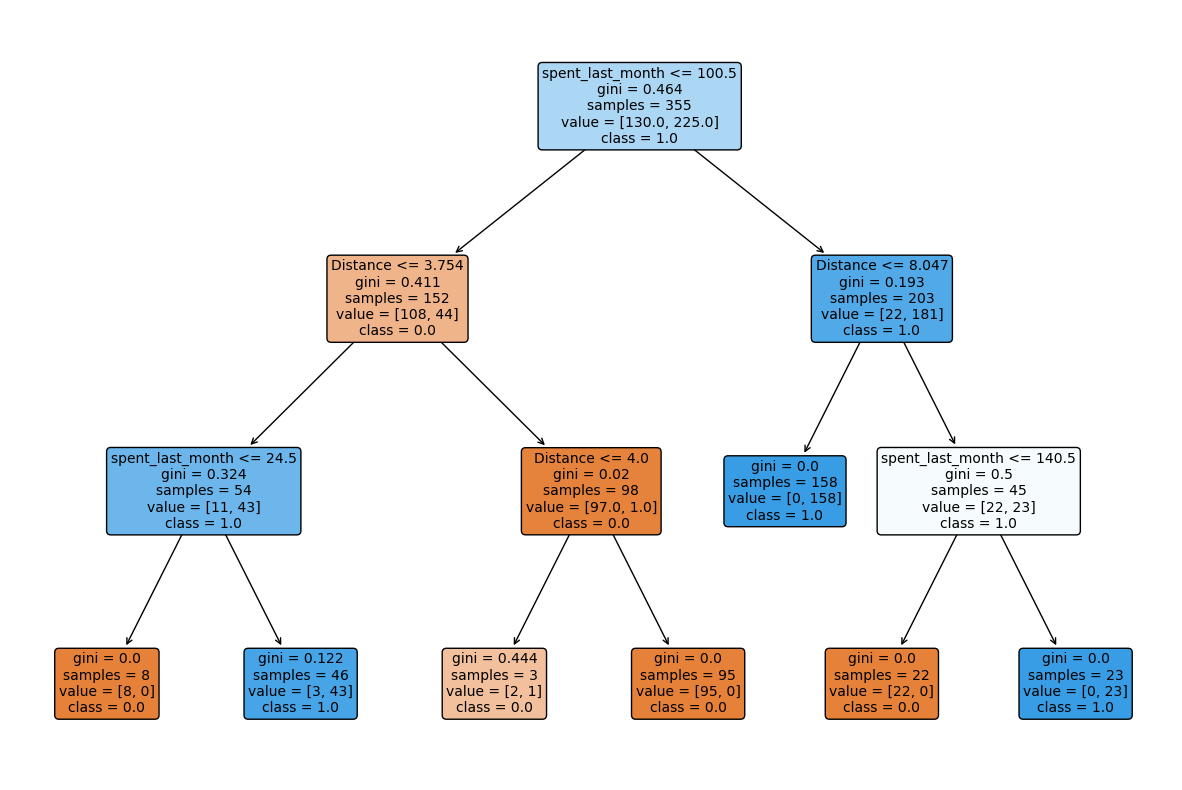

In [223]:
dot_data = StringIO()


# Alternatively for class_names use gini_model2.classes_
plt.figure(figsize=(15, 10))

plot_tree(
    gini_model2,
    feature_names=X_encoded.columns,  # Use your encoded feature names
    class_names=gini_model2.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

In [225]:
print("Gini impurity  model - max depth 3")
print("Accuracy:", metrics.accuracy_score(y_test,y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test,y_pred))
print('Precision score', metrics.precision_score(y_test, y_pred, pos_label=1.0))
print('Recall score', metrics.recall_score(y_test, y_pred, pos_label=1.0))


Gini impurity  model - max depth 3
Accuracy: 0.9747899159663865
Balanced accuracy: 0.9691994996873046
Precision score 0.9746835443037974
Recall score 0.9871794871794872


Now this is an elegant tree. Its accuracy might not be the highest, but it's still the best model we've produced so far. Why is that? Write your answer here: 

In [250]:
#Visually speaking, the tree is very balanced by comparison and it is easier to see the distribution.
#The metrics, though, seem almost exactly the same for all intents and purposes.

# 4. Evaluating and concluding
## 4a. How many customers will buy Hidden Farm coffee? 
Let's first ascertain how many loyal customers claimed, in the survey, that they will purchase the Hidden Farm coffee. 

In [226]:
# Call value_counts() on the 'Decision' column of the original coffeeData
RRD['Decision'].value_counts()

Decision
1.0    303
0.0    171
Name: count, dtype: int64

Let's now determine the number of people that, according to the model, will be willing to buy the Hidden Farm coffee. 
1. First we subset the Prediction dataset into `new_X` considering all the variables except `Decision` 
2. Use that dataset to predict a new variable called `potential_buyers`

In [227]:
# Feature selection
# Make a variable called feature_cols, and assign it a list containing all the column names except 'Decision'
feature_cols = [col for col in RRD.columns if col != 'Decision']

# Make a variable called new_X, and assign it the subset of Prediction, containing just the feature_cols 
new_X = RRD[feature_cols]

In [228]:
# Call get_dummies() on the Pandas object pd, with new_X plugged in, to one-hot encode all features in the training set
new_X_encoded = pd.get_dummies(new_X)

# Make a variable called potential_buyers, and assign it the result of calling predict() on a model of your choice; 
# don't forget to pass new_X to predict()
new_X_aligned = new_X_encoded.reindex(columns=X_encoded.columns, fill_value=0)

#potential_buyers = gini_model2.predict(new_X_aligned)
potential_buyers = gini_model2.predict(new_X_aligned)




In [229]:
# Let's get the numbers of YES's and NO's in the potential buyers 
# Call unique() on np, and pass potential_buyers and return_counts=True 
np.unique(potential_buyers, return_counts=True)


(array(['0.0', '1.0'], dtype=object), array([213, 489], dtype=int64))

The total number of potential buyers is 303 + 183 = 486

In [230]:
# Print the total number of surveyed people 
print("Total number of potential buyers:", 486)

Total number of potential buyers: 486


In [231]:
# Let's calculate the proportion of buyers
486/len(RRD)

0.6923076923076923

In [232]:
# Print the percentage of people who want to buy the Hidden Farm coffee, by our model 
print(round(486/len(RRD)*100,2), "%")

69.23 %


## 4b. Decision
Remember how you thought at the start: if more than 70% of the interviewed customers are likely to buy the Hidden Farm coffee, you will strike the deal with the local Hidden Farm farmers and sell the coffee. Otherwise, you won't strike the deal and the Hidden Farm coffee will remain in legends only. Well now's crunch time. Are you going to go ahead with that idea? If so, you won't be striking the deal with the Chinese farmers. 

They're called `decision trees`, aren't they? So where's the decision? What should you do? (Cue existential cat emoji). 

Ultimately, though, we can't write an algorithm to actually *make the business decision* for us. This is because such decisions depend on our values, what risks we are willing to take, the stakes of our decisions, and how important it us for us to *know* that we will succeed. What are you going to do with the models you've made? Are you going to risk everything, strike the deal with the *Hidden Farm* farmers, and sell the coffee? 

The philosopher of language Jason Stanley once wrote that the number of doubts our evidence has to rule out in order for us to know a given proposition depends on our stakes: the higher our stakes, the more doubts our evidence has to rule out, and therefore the harder it is for us to know things. We can end up paralyzed in predicaments; sometimes, we can act to better our situation only if we already know certain things, which we can only if our stakes were lower and we'd *already* bettered our situation. 

Data science and machine learning can't solve such problems. But what it can do is help us make great use of our data to help *inform* our decisions.

## 5. Random Forest
You might have noticed an important fact about decision trees. Each time we run a given decision tree algorithm to make a prediction (such as whether customers will buy the Hidden Farm coffee) we will actually get a slightly different result. This might seem weird, but it has a simple explanation: machine learning algorithms are by definition ***stochastic***, in that their output is at least partly determined by randomness. 

To account for this variability and ensure that we get the most accurate prediction, we might want to actually make lots of decision trees, and get a value that captures the centre or average of the outputs of those trees. Luckily, there's a method for this, known as the ***Random Forest***. 

Essentially, Random Forest involves making lots of trees with similar properties, and then performing summary statistics on the outputs of those trees to reach that central value. Random forests are hugely powerful classifers, and they can improve predictive accuracy and control over-fitting. 

Why not try to inform your decision with random forest? You'll need to make use of the RandomForestClassifier function within the sklearn.ensemble module, found [here](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html). 

### 5a. Import necessary modules

In [233]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

### 5b. Model
You'll use your X_train and y_train variables just as before.

You'll then need to make a variable (call it firstRFModel) to store your new Random Forest model. You'll assign this variable the result of calling RandomForestClassifier().

Then, just as before, you'll call fit() on that firstRFModel variable, and plug in X_train and y_train.

Finally, you should make a variable called y_pred, and assign it the result of calling the predict() method on your new firstRFModel, with the X_test data passed to it. 

In [237]:
firstRFModel = RandomForestClassifier()

firstRFModel.fit(X_train, y_train)

y_pred = firstRFModel.predict(X_test)

array(['1.0', '1.0', '0.0', '0.0', '0.0', '1.0', '1.0', '0.0', '0.0',
       '1.0', '1.0', '1.0', '0.0', '0.0', '1.0', '0.0', '1.0', '1.0',
       '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '0.0', '1.0', '0.0',
       '1.0', '0.0', '0.0', '0.0', '1.0', '1.0', '1.0', '0.0', '1.0',
       '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '0.0', '1.0', '1.0',
       '0.0', '1.0', '0.0', '1.0', '0.0', '0.0', '1.0', '0.0', '1.0',
       '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0',
       '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0',
       '1.0', '1.0', '0.0', '0.0', '0.0', '1.0', '1.0', '1.0', '1.0',
       '0.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '0.0', '0.0',
       '0.0', '0.0', '0.0', '0.0', '1.0', '1.0', '1.0', '0.0', '0.0',
       '0.0', '0.0', '0.0', '1.0', '0.0', '0.0', '0.0', '1.0', '0.0',
       '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '1.0', '0.0',
       '1.0', '1.0'], dtype=object)

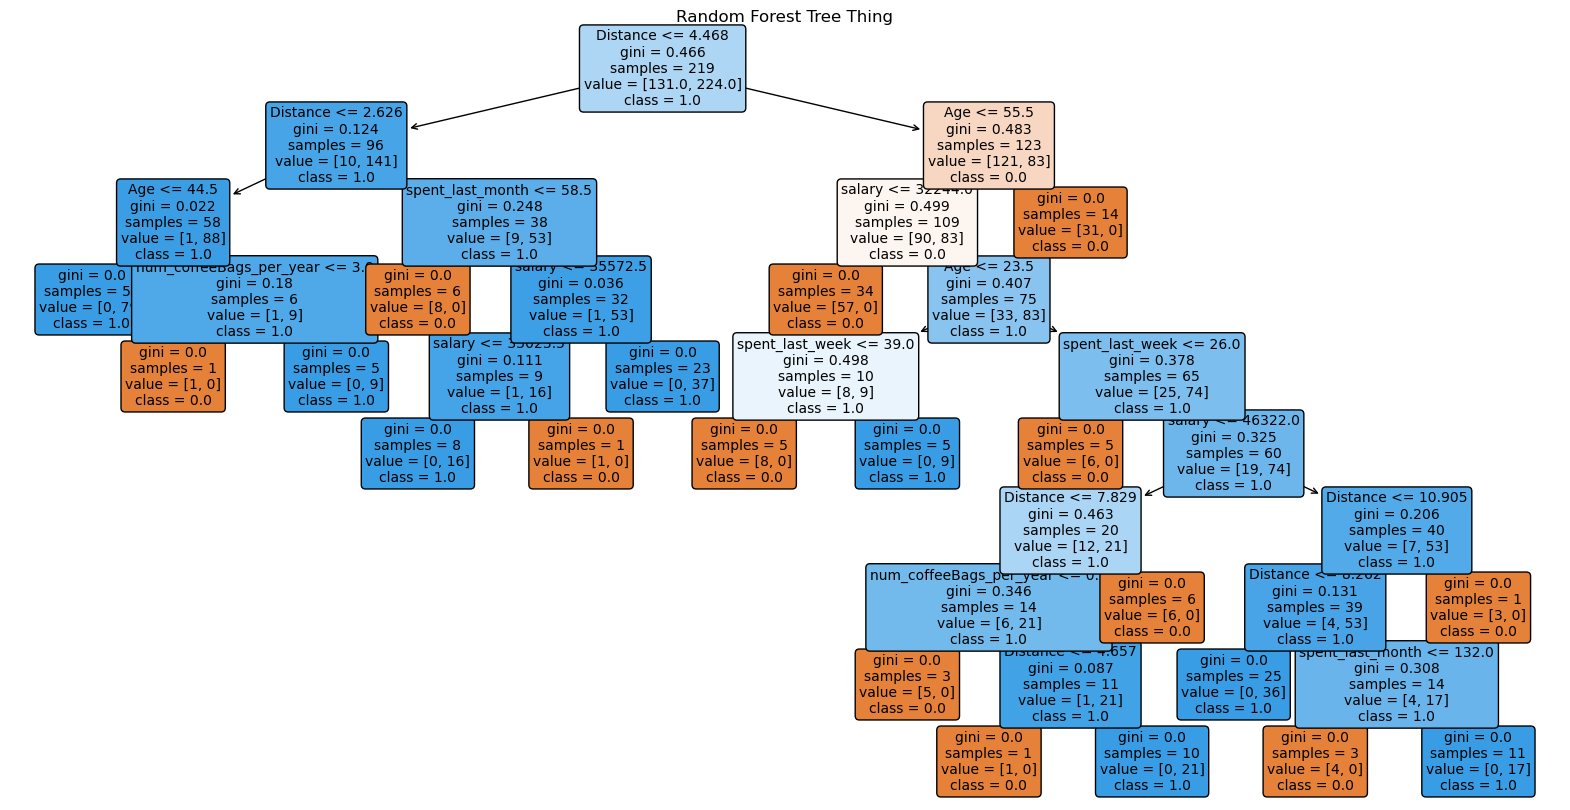

Random Forest model - max depth 3
Accuracy: 0.9747899159663865
Balanced accuracy: 0.9691994996873046
Precision score 0.9746835443037974
Recall score 0.9871794871794872


In [245]:
dot_data = StringIO()

estimator = firstRFModel.estimators_[0]

y_pred = np.array(y_pred).astype(float)

plt.figure(figsize=(20, 10))
plot_tree(
    estimator,
    feature_names=X_train.columns, 
    class_names=firstRFModel.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Random Forest Tree Thing")
plt.show()

from sklearn import metrics
import numpy as np

y_pred = np.array(y_pred).astype(float)

print("Random Forest model - max depth 3")
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Balanced accuracy:", metrics.balanced_accuracy_score(y_test, y_pred))
print('Precision score', metrics.precision_score(y_test, y_pred, pos_label=1.0))
print('Recall score', metrics.recall_score(y_test, y_pred, pos_label=1.0))


### 5c. Revise conclusion

Has your conclusion changed? Or is the result of executing random forest the same as your best model reached by a single decision tree? 

In [252]:
#The models all do well in their accuracy and score, so I think the next thing to do would be to cross-validate for confirmation.
#The Gini impurity model has the best tree, though!